In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("E:/User_Funnel/customer_journey_clean.csv")
session_summary = pd.read_csv("E:/User_Funnel/session_summary.csv")
session_master = pd.read_csv("E:/User_Funnel/session_master.csv")
funnel_summary = pd.read_csv("E:/User_Funnel/funnel_summary.csv")

print("Files loaded successfully.")

Files loaded successfully.


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
session_summary['session_start'] = pd.to_datetime(session_summary['session_start'])
session_summary['session_end'] = pd.to_datetime(session_summary['session_end'])

print("Datetime columns converted.")

Datetime columns converted.


In [4]:
print("Event-level shape:", df.shape)
print("Session summary shape:", session_summary.shape)
print("Session master shape:", session_master.shape)

Event-level shape: (12719, 17)
Session summary shape: (5000, 12)
Session master shape: (5000, 17)


In [5]:
total_sessions = session_master['session_id'].nunique()
purchased_sessions = session_master['purchased'].sum()
overall_conversion = (purchased_sessions / total_sessions) * 100

print("Total Sessions:", total_sessions)
print("Purchased Sessions:", purchased_sessions)
print("Overall Conversion Rate %:", round(overall_conversion, 2))

Total Sessions: 5000
Purchased Sessions: 1010
Overall Conversion Rate %: 20.2


In [6]:
funnel_summary

,stage,sessions
0,home,5000
1,product_page,3987
2,cart,1599
3,checkout,1123
4,confirmation,1010
5,purchased,1010


In [7]:
#Drop off metrics
funnel_summary['previous_stage_sessions'] = funnel_summary['sessions'].shift(1)
funnel_summary['drop_off'] = funnel_summary['previous_stage_sessions'] - funnel_summary['sessions']
funnel_summary['conversion_from_previous_%'] = (funnel_summary['sessions'] / funnel_summary['previous_stage_sessions']) * 100

funnel_summary

,stage,sessions,previous_stage_sessions,drop_off,conversion_from_previous_%
0,home,5000,NaN,NaN,NaN
1,product_page,3987,5000.0,1013.0,79.740000
2,cart,1599,3987.0,2388.0,40.105342
3,checkout,1123,1599.0,476.0,70.231395
4,confirmation,1010,1123.0,113.0,89.937667
5,purchased,1010,1010.0,0.0,100.000000


In [8]:
#Clean first row issue
funnel_summary['drop_off'] = funnel_summary['drop_off'].fillna(0)
funnel_summary['conversion_from_previous_%'] = funnel_summary['conversion_from_previous_%'].fillna(100)

funnel_summary

,stage,sessions,previous_stage_sessions,drop_off,conversion_from_previous_%
0,home,5000,NaN,0.0,100.000000
1,product_page,3987,5000.0,1013.0,79.740000
2,cart,1599,3987.0,2388.0,40.105342
3,checkout,1123,1599.0,476.0,70.231395
4,confirmation,1010,1123.0,113.0,89.937667
5,purchased,1010,1010.0,0.0,100.000000


In [9]:
funnel_summary.to_csv("E:/User_Funnel/funnel_summary_enhanced.csv", index=False)

print("Enhanced funnel summary saved.")

Enhanced funnel summary saved.


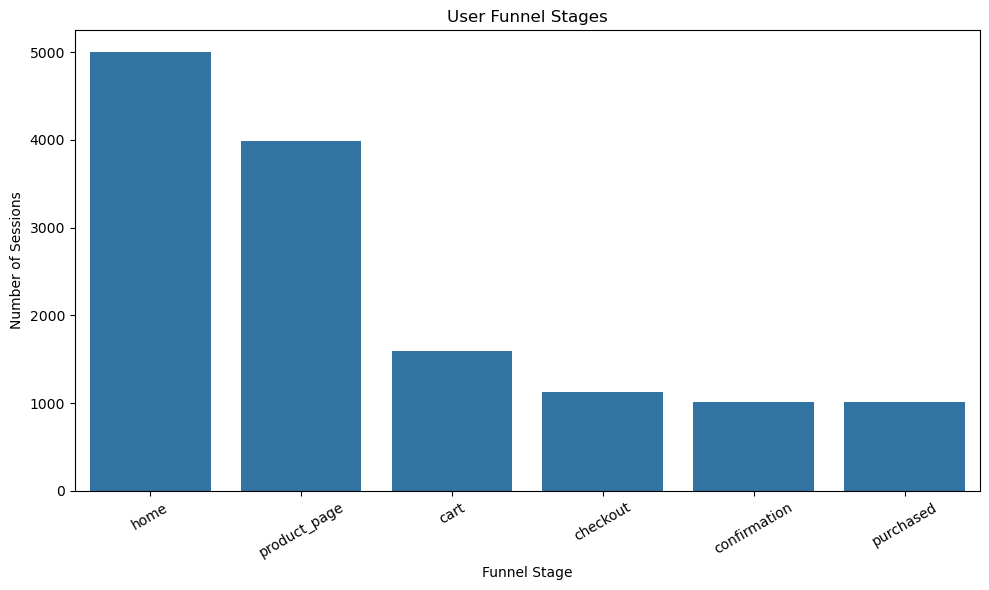

In [10]:
#Funnel chart
plt.figure(figsize=(10,6))
sns.barplot(data=funnel_summary, x='stage', y='sessions')
plt.title("User Funnel Stages")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

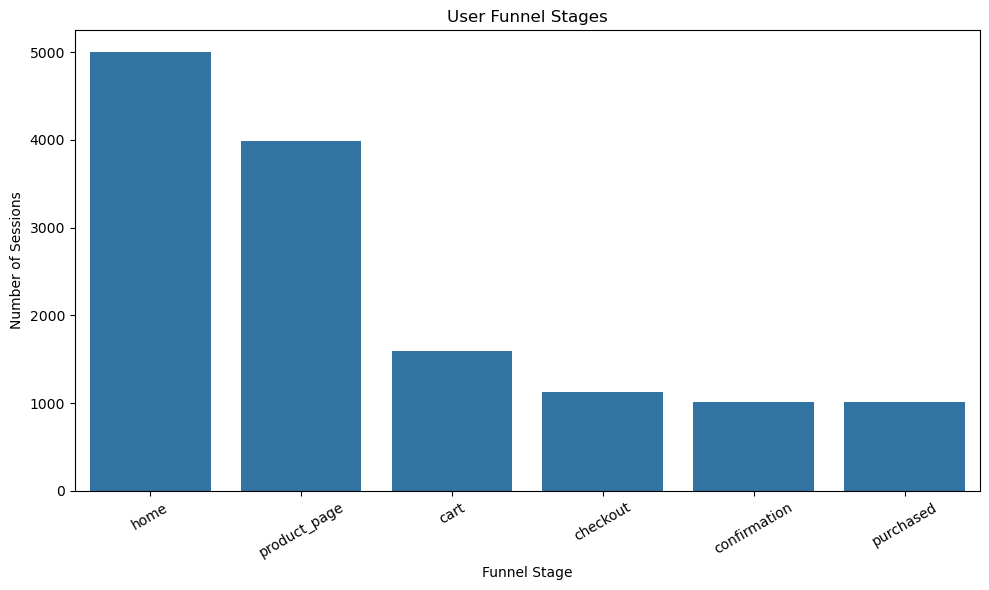

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(data=funnel_summary, x='stage', y='sessions')
plt.title("User Funnel Stages")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("E:/User_Funnel/outputs/funnel_stages.png")
plt.show()

In [12]:
#Device-wise conversion analysis
device_conversion = session_master.groupby('device_type').agg(
    total_sessions=('session_id', 'count'),
    purchased_sessions=('purchased', 'sum')
).reset_index()

device_conversion['conversion_rate_%'] = (
    device_conversion['purchased_sessions'] / device_conversion['total_sessions']
) * 100

device_conversion.sort_values(by='conversion_rate_%', ascending=False)

,device_type,total_sessions,purchased_sessions,conversion_rate_%
0,desktop,1666,339,20.348139
1,mobile,1671,337,20.167564
2,tablet,1663,334,20.084185


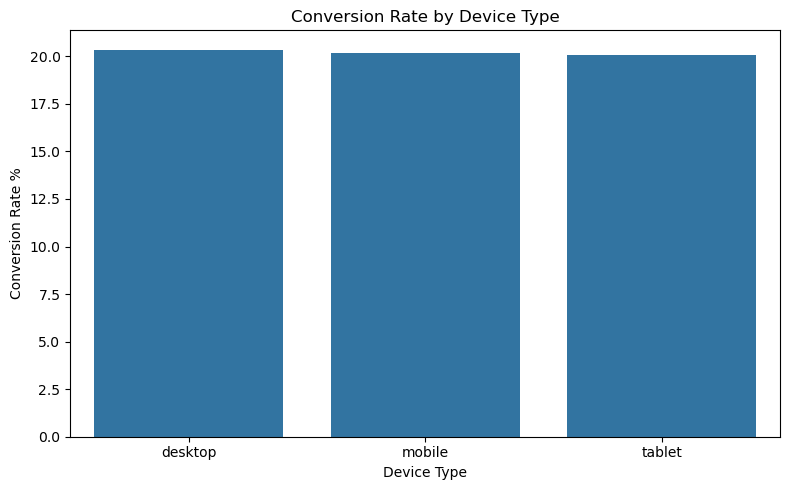

In [13]:
#Device conversion chart
plt.figure(figsize=(8,5))
sns.barplot(data=device_conversion, x='device_type', y='conversion_rate_%')
plt.title("Conversion Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate %")
plt.tight_layout()
plt.show()

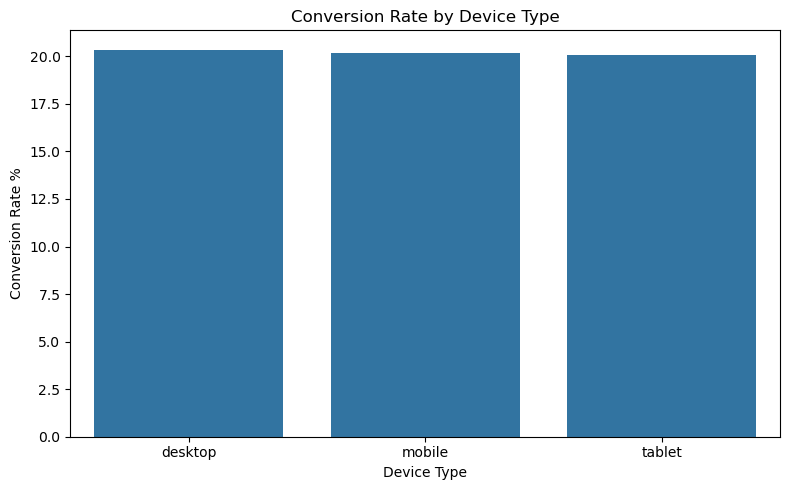

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=device_conversion, x='device_type', y='conversion_rate_%')
plt.title("Conversion Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate %")
plt.tight_layout()
plt.savefig("E:/User_Funnel/outputs/device_conversion.png")
plt.show()

In [15]:
#Referral source conversion analysis
source_conversion = session_master.groupby('referral_source').agg(
    total_sessions=('session_id', 'count'),
    purchased_sessions=('purchased', 'sum')
).reset_index()

source_conversion['conversion_rate_%'] = (
    source_conversion['purchased_sessions'] / source_conversion['total_sessions']
) * 100

source_conversion.sort_values(by='conversion_rate_%', ascending=False)

,referral_source,total_sessions,purchased_sessions,conversion_rate_%
2,google,1280,277,21.640625
1,email,1251,251,20.063949
0,direct,1226,243,19.820555
3,social media,1243,239,19.227675


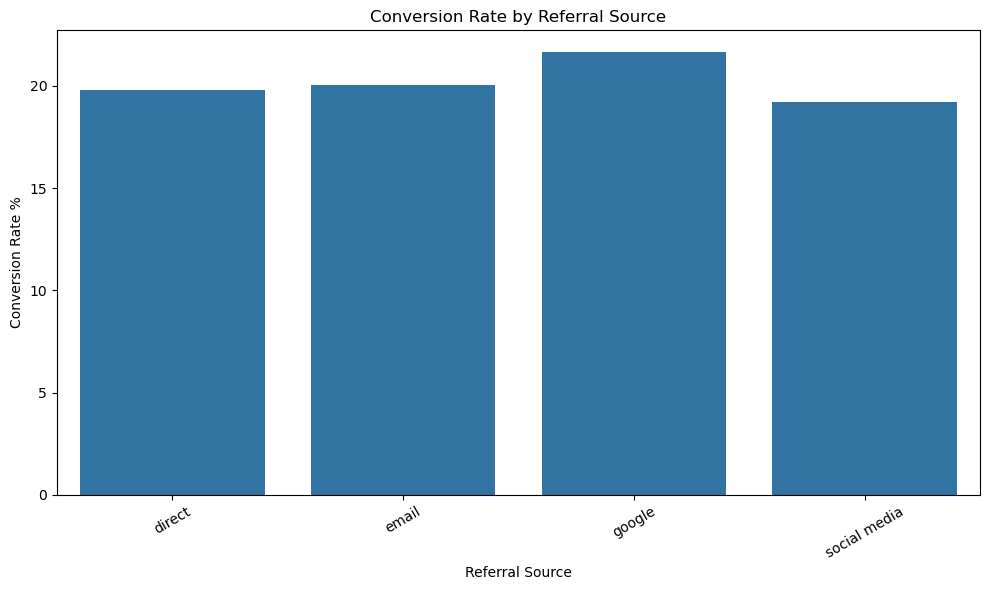

In [16]:
#Referral source chart
plt.figure(figsize=(10,6))
sns.barplot(data=source_conversion, x='referral_source', y='conversion_rate_%')
plt.title("Conversion Rate by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Conversion Rate %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

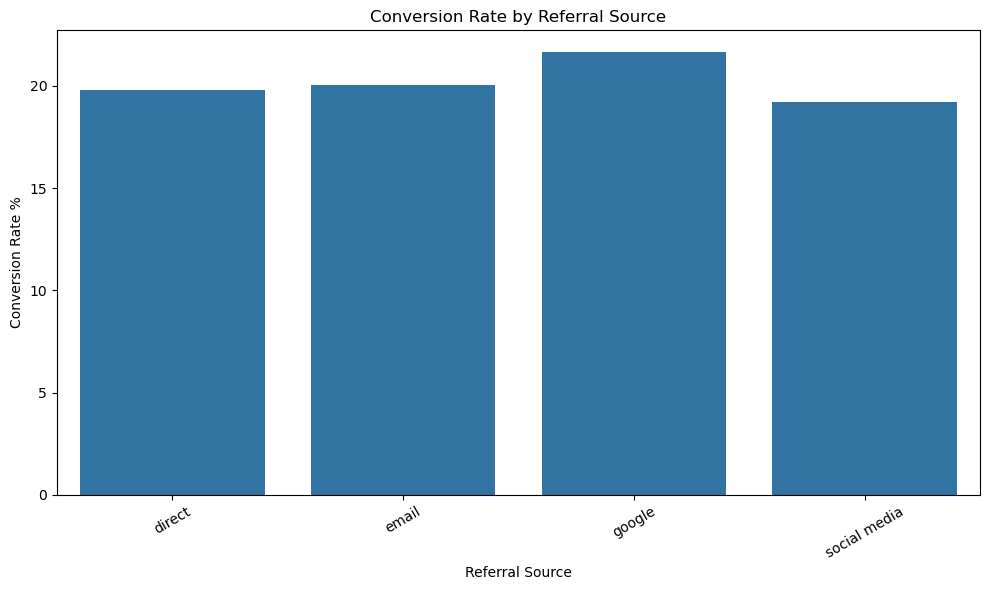

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=source_conversion, x='referral_source', y='conversion_rate_%')
plt.title("Conversion Rate by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Conversion Rate %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("E:/User_Funnel/outputs/source_conversion.png")
plt.show()

In [18]:
#Country-wise conversion
country_conversion = session_master.groupby('country').agg(
    total_sessions=('session_id', 'count'),
    purchased_sessions=('purchased', 'sum')
).reset_index()

country_conversion['conversion_rate_%'] = (
    country_conversion['purchased_sessions'] / country_conversion['total_sessions']
) * 100

country_conversion.sort_values(by='conversion_rate_%', ascending=False)

,country,total_sessions,purchased_sessions,conversion_rate_%
2,france,752,170,22.606383
6,usa,706,147,20.821530
4,india,702,145,20.655271
5,uk,739,145,19.621110
1,canada,715,140,19.580420
0,australia,683,131,19.180088
3,germany,703,132,18.776671


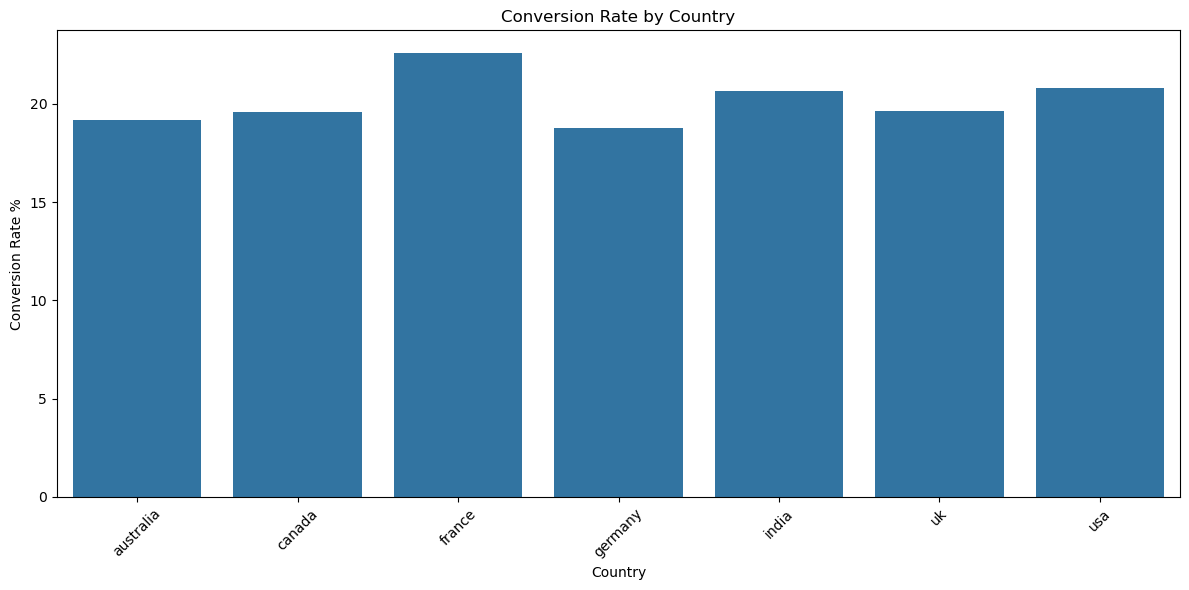

In [19]:
#Country chart
plt.figure(figsize=(12,6))
sns.barplot(data=country_conversion, x='country', y='conversion_rate_%')
plt.title("Conversion Rate by Country")
plt.xlabel("Country")
plt.ylabel("Conversion Rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

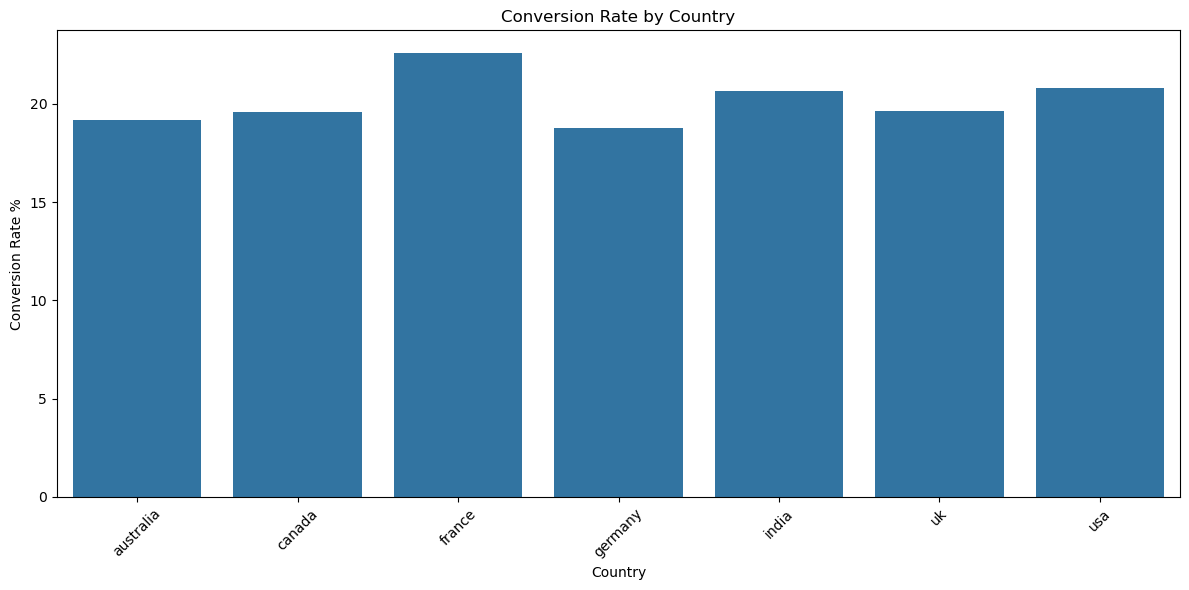

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(data=country_conversion, x='country', y='conversion_rate_%')
plt.title("Conversion Rate by Country")
plt.xlabel("Country")
plt.ylabel("Conversion Rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("E:/User_Funnel/outputs/country_conversion.png")
plt.show()

In [21]:
#Engagement analysis: pages visited
session_summary['total_pages_visited'].describe()

count    5000.00000
mean        2.54380
std         1.38234
min         1.00000
25%         2.00000
50%         2.00000
75%         3.00000
max         5.00000
Name: total_pages_visited, dtype: float64

In [22]:
#Engagement analysis: total time spent
session_summary['total_time_spent_seconds'].describe()

count    5000.000000
mean      247.836600
std       154.141394
min        15.000000
25%       136.000000
50%       211.000000
75%       320.000000
max       821.000000
Name: total_time_spent_seconds, dtype: float64

In [23]:
#Compare engagement between purchased vs non-purchased
engagement_comparison = session_master.groupby('purchased').agg(
    avg_pages_visited=('total_pages_visited', 'mean'),
    avg_time_spent_seconds=('total_time_spent_seconds', 'mean'),
    avg_session_duration_minutes=('session_duration_minutes', 'mean'),
    avg_items_in_cart=('max_items_in_cart', 'mean')
).reset_index()

engagement_comparison

,purchased,avg_pages_visited,avg_time_spent_seconds,avg_session_duration_minutes,avg_items_in_cart
0,0,1.922055,187.809774,1.495860,1.445113
1,1,5.000000,484.972277,6.470627,2.889109


In [24]:
#Make purchased labels readable
engagement_comparison['purchase_status'] = engagement_comparison['purchased'].map({
    0: 'Not Purchased',
    1: 'Purchased'
})

engagement_comparison

,purchased,avg_pages_visited,avg_time_spent_seconds,avg_session_duration_minutes,avg_items_in_cart,purchase_status
0,0,1.922055,187.809774,1.495860,1.445113,Not Purchased
1,1,5.000000,484.972277,6.470627,2.889109,Purchased


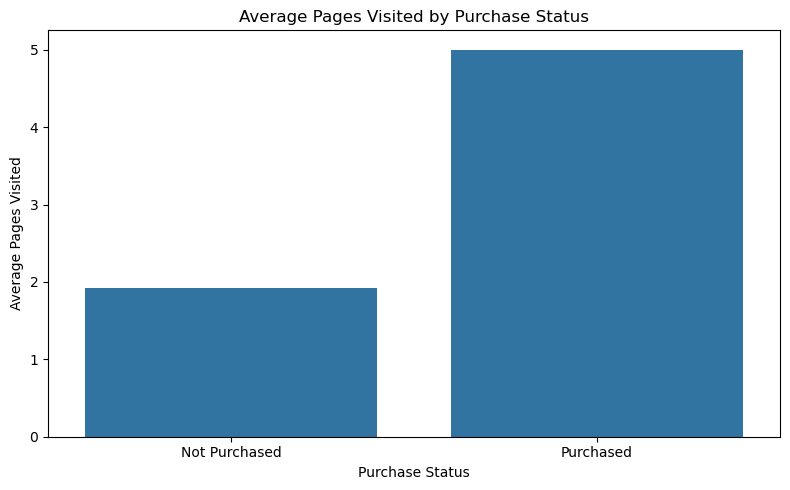

In [25]:
#Chart: Avg pages visited by purchase status
plt.figure(figsize=(8,5))
sns.barplot(data=engagement_comparison, x='purchase_status', y='avg_pages_visited')
plt.title("Average Pages Visited by Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Average Pages Visited")
plt.tight_layout()
plt.show()

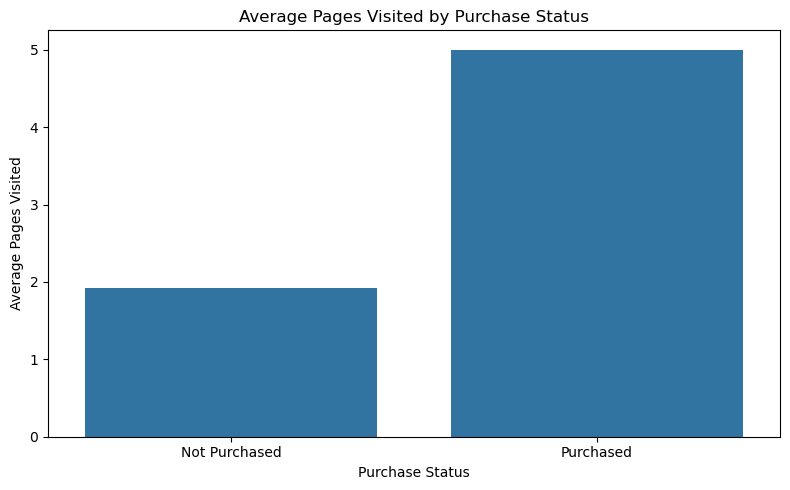

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(data=engagement_comparison, x='purchase_status', y='avg_pages_visited')
plt.title("Average Pages Visited by Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Average Pages Visited")
plt.tight_layout()
plt.savefig("E:/User_Funnel/outputs/avg_pages_by_purchase.png")
plt.show()

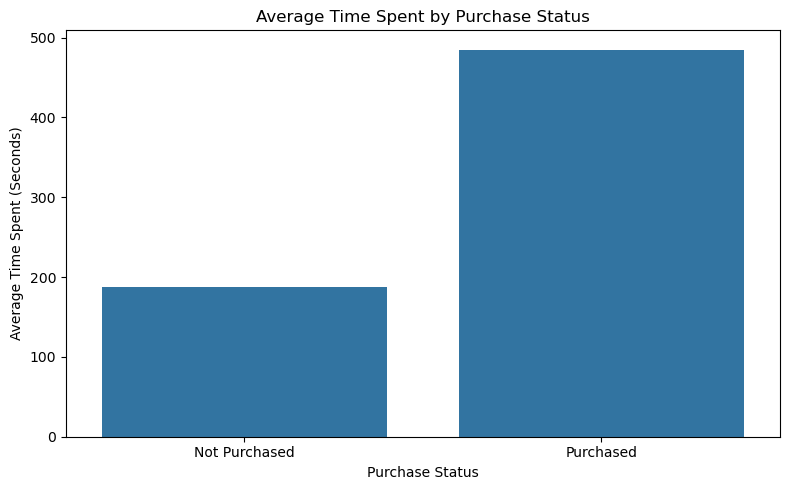

In [27]:
#Chart: Avg time spent by purchase status
plt.figure(figsize=(8,5))
sns.barplot(data=engagement_comparison, x='purchase_status', y='avg_time_spent_seconds')
plt.title("Average Time Spent by Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Average Time Spent (Seconds)")
plt.tight_layout()
plt.show()

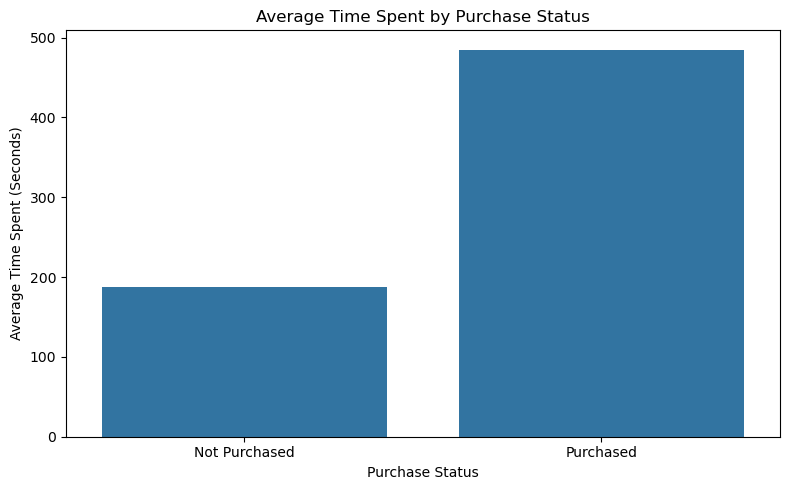

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(data=engagement_comparison, x='purchase_status', y='avg_time_spent_seconds')
plt.title("Average Time Spent by Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Average Time Spent (Seconds)")
plt.tight_layout()
plt.savefig("E:/User_Funnel/outputs/avg_time_by_purchase.png")
plt.show()

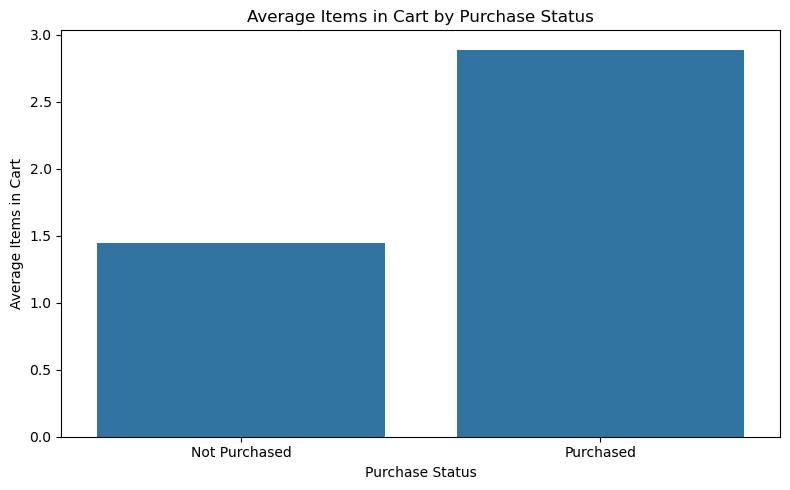

In [29]:
#Chart: Avg items in cart by purchase status
plt.figure(figsize=(8,5))
sns.barplot(data=engagement_comparison, x='purchase_status', y='avg_items_in_cart')
plt.title("Average Items in Cart by Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Average Items in Cart")
plt.tight_layout()
plt.savefig("E:/User_Funnel/outputs/items_in_cart_by_purchase.png")
plt.show()

In [30]:
print(session_summary.columns.tolist())

['session_id', 'user_id', 'session_start', 'session_end', 'total_pages_visited', 'total_time_spent_seconds', 'max_items_in_cart', 'purchased', 'device_type', 'country', 'referral_source', 'session_duration_minutes']


In [31]:
# Recreate last_page_visited from event-level data
last_page = df.sort_values(['session_id', 'timestamp']).groupby('session_id').tail(1)[['session_id', 'page_type']]
last_page = last_page.rename(columns={'page_type': 'last_page_visited'})

last_page.head()

,session_id,last_page_visited
0,session_0,home
2,session_1,product_page
4,session_10,product_page
6,session_100,product_page
11,session_1000,confirmation


In [32]:
# Remove old column if it somehow exists partially
if 'last_page_visited' in session_summary.columns:
    session_summary = session_summary.drop(columns=['last_page_visited'])

# Merge properly
session_summary = session_summary.merge(last_page, on='session_id', how='left')

session_summary.head()

,session_id,user_id,session_start,session_end,total_pages_visited,total_time_spent_seconds,max_items_in_cart,purchased,device_type,country,referral_source,session_duration_minutes,last_page_visited
0,session_0,user_2223,2025-01-20 22:53:34,2025-01-20 22:53:34,1,55.0,0.0,0,desktop,india,social media,0.000000,home
1,session_1,user_2192,2025-02-26 12:57:10,2025-02-26 12:59:11,2,220.0,0.0,0,tablet,germany,email,2.016667,product_page
2,session_10,user_2357,2025-05-17 22:11:37,2025-05-17 22:13:33,2,191.0,0.0,0,tablet,india,direct,1.933333,product_page
3,session_100,user_1233,2025-04-02 11:24:36,2025-04-02 11:25:41,2,101.0,1.0,0,desktop,usa,email,1.083333,product_page
4,session_1000,user_1551,2025-08-25 09:34:15,2025-08-25 09:41:24,5,474.0,3.0,1,mobile,france,email,7.150000,confirmation


In [33]:
#Drop-off analysis using last page visited
drop_off_analysis = session_summary['last_page_visited'].value_counts().reset_index()
drop_off_analysis.columns = ['last_page_visited', 'sessions_dropped_here']

drop_off_analysis

,last_page_visited,sessions_dropped_here
0,product_page,2388
1,home,1013
2,confirmation,1010
3,cart,476
4,checkout,113


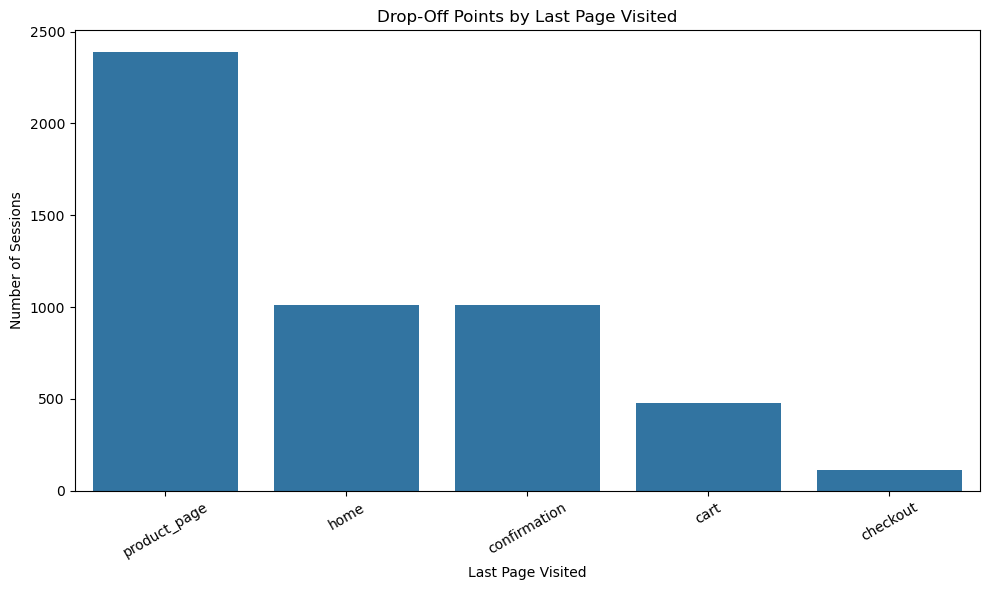

In [34]:
#Drop-off chart
plt.figure(figsize=(10,6))
sns.barplot(data=drop_off_analysis, x='last_page_visited', y='sessions_dropped_here')
plt.title("Drop-Off Points by Last Page Visited")
plt.xlabel("Last Page Visited")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("E:/User_Funnel/outputs/drop_off_points.png")
plt.show()

In [35]:
device_conversion.to_csv("E:/User_Funnel/data/cleaned/device_conversion.csv", index=False)
source_conversion.to_csv("E:/User_Funnel/data/cleaned/source_conversion.csv", index=False)
country_conversion.to_csv("E:/User_Funnel/data/cleaned/country_conversion.csv", index=False)
engagement_comparison.to_csv("E:/User_Funnel/data/cleaned/engagement_comparison.csv", index=False)
drop_off_analysis.to_csv("E:/User_Funnel/data/cleaned/drop_off_analysis.csv", index=False)

print("All EDA tables saved successfully.")

All EDA tables saved successfully.


In [36]:
# Recreate last_page_visited from event-level data
last_page = df.sort_values(['session_id', 'timestamp']).groupby('session_id').tail(1)[['session_id', 'page_type']]
last_page = last_page.rename(columns={'page_type': 'last_page_visited'})

# Remove old column if exists
if 'last_page_visited' in session_summary.columns:
    session_summary = session_summary.drop(columns=['last_page_visited'])

# Merge into session_summary
session_summary = session_summary.merge(last_page, on='session_id', how='left')

# Merge into session_master too
if 'last_page_visited' in session_master.columns:
    session_master = session_master.drop(columns=['last_page_visited'])

session_master = session_master.merge(last_page, on='session_id', how='left')

# Save corrected CSV
session_master.to_csv("E:/User_Funnel/data/cleaned/session_master.csv", index=False)

print("Corrected session_master.csv saved successfully.")

Corrected session_master.csv saved successfully.
